In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

In [3]:
# Replace with your CSV file name
df = pd.read_csv("global_air _pollution_dataset.csv")

In [4]:
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [6]:
df.isnull().sum()

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

In [7]:
df.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [8]:
df.columns

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')

In [9]:
top_polluted = (
    df.groupby("Country")["AQI Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_polluted

Country
Republic of Korea       421.000000
Bahrain                 188.000000
Mauritania              179.000000
Pakistan                178.788274
United Arab Emirates    163.666667
Aruba                   163.000000
Kuwait                  162.000000
Qatar                   157.500000
India                   152.964228
Senegal                 152.424242
Name: AQI Value, dtype: float64

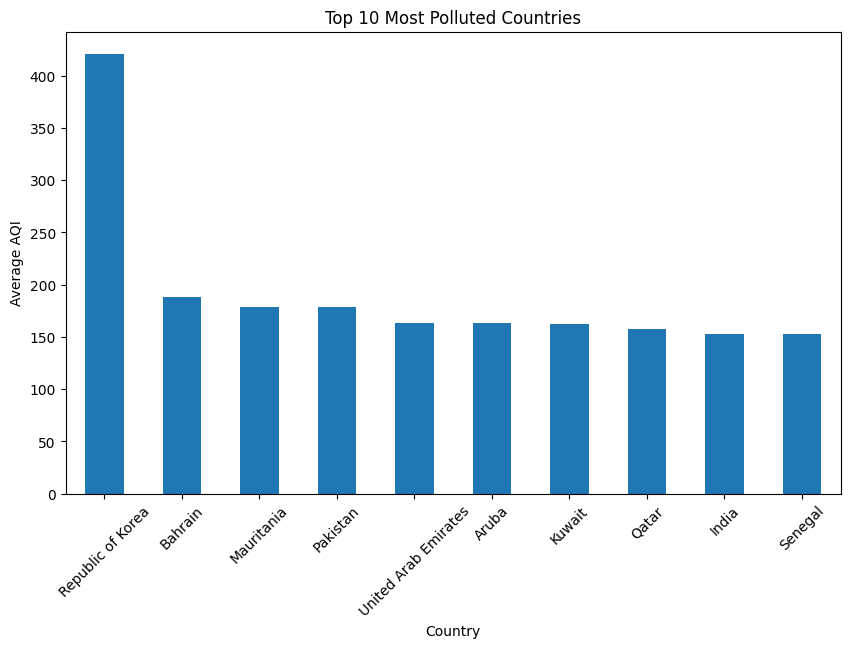

In [10]:
top_polluted.plot(kind="bar")

plt.title("Top 10 Most Polluted Countries")
plt.xlabel("Country")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)
plt.savefig("polluted_countries.png", bbox_inches='tight')
plt.show()

In [11]:
cleanest = (
    df.groupby("Country")["AQI Value"]
    .mean()
    .sort_values()
    .head(10)
)

cleanest

Country
Palau                               16.000000
Solomon Islands                     18.000000
Maldives                            19.000000
Iceland                             23.000000
Bolivia (Plurinational State of)    23.787879
Papua New Guinea                    24.866667
Seychelles                          26.000000
Bhutan                              26.000000
Uruguay                             26.653846
Argentina                           28.235294
Name: AQI Value, dtype: float64

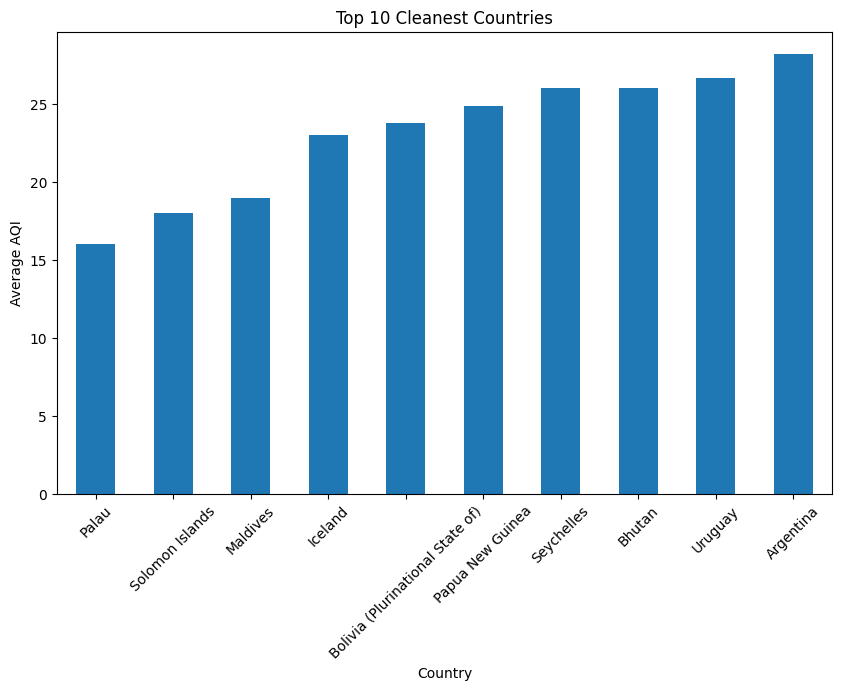

In [12]:
cleanest.plot(kind="bar")

plt.title("Top 10 Cleanest Countries")
plt.xlabel("Country")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)
plt.savefig("cleanest_countries.png", bbox_inches='tight')
plt.show()

In [13]:
category_count = df["AQI Category"].value_counts()

category_count

AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

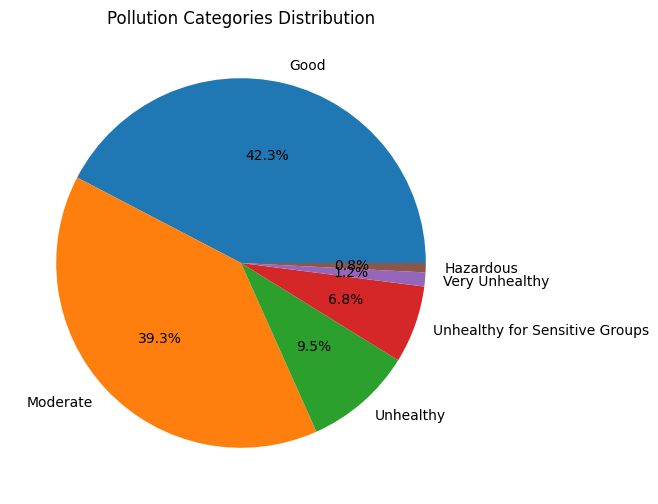

In [14]:
category_count.plot(kind="pie", autopct="%1.1f%%")

plt.title("Pollution Categories Distribution")
plt.ylabel("")
plt.savefig("AQI_categories.png", bbox_inches='tight')

plt.show()


In [15]:
top_cities = (
    df.groupby("City")["AQI Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_cities

City
Nagaur          500.0
Julana          500.0
Hodal           500.0
Chhachhrauli    500.0
Aonla           500.0
Kandhla         500.0
Kanina          500.0
Jodhpur         500.0
Sunam           500.0
Hastinapur      500.0
Name: AQI Value, dtype: float64

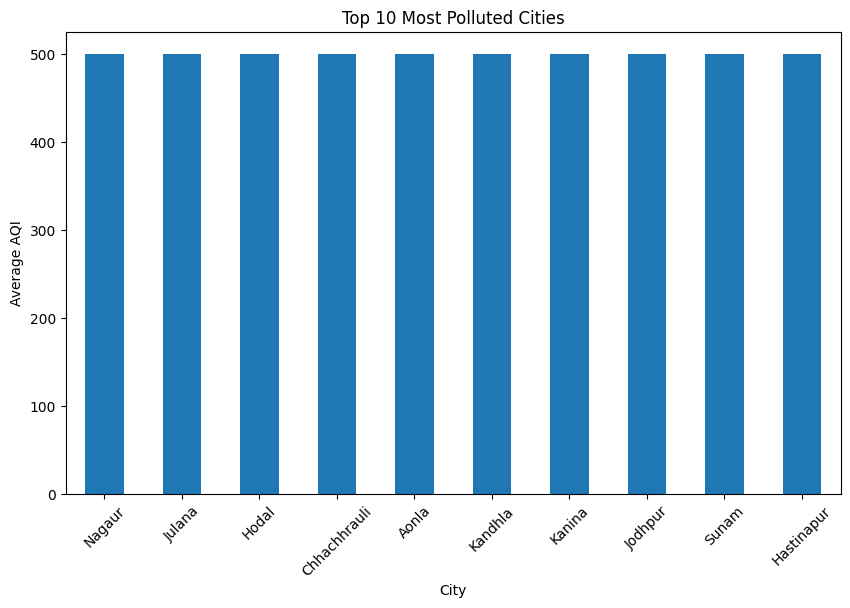

In [16]:
top_cities.plot(kind="bar")

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)
plt.savefig("polluted_cities.png", bbox_inches='tight')

plt.show()

In [17]:
print("EDA COMPLETED SUCCESSFULLY")

print("""
Important findings for infographic:
1. Top polluted countries
2. Cleanest countries
3. Pollution category distribution
4. Most polluted cities
5. AQI comparisons
""")

EDA COMPLETED SUCCESSFULLY

Important findings for infographic:
1. Top polluted countries
2. Cleanest countries
3. Pollution category distribution
4. Most polluted cities
5. AQI comparisons

